In [1]:
from google.colab import drive

drive.mount("/content/drive")


Mounted at /content/drive


In [2]:
##Configurar pastas e carregar a base limpa
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

PROJECT_DIR = Path("/content/drive/MyDrive/portfolio/shopmais-churn-eda")

RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
REPORTS_DIR = PROJECT_DIR / "reports"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

IMAGES_DIR = PROJECT_DIR / "images"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

print("Pasta de imagens:", IMAGES_DIR)

clean_path = PROCESSED_DIR / "shopmais_churn_clean.csv"

df = pd.read_csv(clean_path)

print("Base carregada com sucesso.")
print("Dimensão:", df.shape)

df.head()

Base carregada com sucesso.
Dimensão: (5630, 27)


,customer_id,churn,tenure,preferred_login_device,city_tier,warehouse_to_home_km,preferred_payment_mode,gender,hours_spent_on_app,number_of_devices_registered,preferred_order_category,satisfaction_score,marital_status,number_of_address,complained,order_amount_hike_from_last_year,coupons_used,order_count,days_since_last_order,cashback_amount,tenure_was_missing,warehouse_to_home_km_was_missing,hours_spent_on_app_was_missing,order_amount_hike_from_last_year_was_missing,coupons_used_was_missing,order_count_was_missing,days_since_last_order_was_missing
0,50001,1,4.00,Mobile Phone,3,6.00,Debit Card,Female,3.00,3,Laptop & Accessory,2,Single,9,1,11.00,1.00,1.00,5.00,159.93,0,0,0,0,0,0,0
1,50002,1,9.00,Phone,1,8.00,UPI,Male,3.00,4,Mobile,3,Single,7,1,15.00,0.00,1.00,0.00,120.90,1,0,0,0,0,0,0
2,50003,1,9.00,Phone,1,30.00,Debit Card,Male,2.00,4,Mobile,3,Single,6,1,14.00,0.00,1.00,3.00,120.28,1,0,0,0,0,0,0
3,50004,1,0.00,Phone,3,15.00,Debit Card,Male,2.00,4,Laptop & Accessory,5,Single,8,0,23.00,0.00,1.00,3.00,134.07,0,0,0,0,0,0,0
4,50005,1,0.00,Phone,1,12.00,CC,Male,3.00,3,Mobile,5,Single,3,0,11.00,1.00,1.00,3.00,129.60,0,0,1,0,0,0,0


In [3]:
#Conferindo se a base está limpa
missing_total = df.isna().sum().sum()
duplicates_total = df.duplicated().sum()

print("Total de valores nulos:", missing_total)
print("Total de duplicatas exatas:", duplicates_total)

df.info()

Total de valores nulos: 0
Total de duplicatas exatas: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 27 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   customer_id                                   5630 non-null   int64  
 1   churn                                         5630 non-null   int64  
 2   tenure                                        5630 non-null   float64
 3   preferred_login_device                        5630 non-null   object 
 4   city_tier                                     5630 non-null   int64  
 5   warehouse_to_home_km                          5630 non-null   float64
 6   preferred_payment_mode                        5630 non-null   object 
 7   gender                                        5630 non-null   object 
 8   hours_spent_on_app                            5630 non-null   float64
 9   number_

# Engenharia de Features e EDA de Negócio

Nesta etapa, a base limpa será transformada em indicadores de negócio para análise de churn.

O objetivo não é apenas criar gráficos, mas responder perguntas relevantes para uma empresa de e-commerce:

1. Quais clientes apresentam maior risco de churn?
2. O tempo de relacionamento influencia o cancelamento?
3. Reclamações aumentam a chance de churn?
4. Clientes inativos recentemente têm maior risco?
5. Quais segmentos devem ser priorizados pelo time de CRM?

In [4]:
df_fe = df.copy()

# 1. Faixa de tempo de relacionamento
df_fe["tenure_group"] = pd.cut(
    df_fe["tenure"],
    bins=[-0.1, 3, 6, 12, 24, np.inf],
    labels=[
        "0-3 meses",
        "4-6 meses",
        "7-12 meses",
        "13-24 meses",
        "25+ meses"
    ]
)

# 2. Faixa de recência do último pedido
df_fe["recency_group"] = pd.cut(
    df_fe["days_since_last_order"],
    bins=[-0.1, 7, 15, 30, np.inf],
    labels=[
        "0-7 dias",
        "8-15 dias",
        "16-30 dias",
        "31+ dias"
    ]
)

# 3. Grupo de satisfação
df_fe["satisfaction_group"] = pd.cut(
    df_fe["satisfaction_score"],
    bins=[0, 2, 3, 5],
    labels=[
        "baixa satisfação",
        "satisfação neutra",
        "alta satisfação"
    ],
    include_lowest=True
)

# 4. Risco combinado entre reclamação e satisfação
conditions = [
    (df_fe["complained"] == 1) & (df_fe["satisfaction_score"] <= 2),
    (df_fe["complained"] == 1) & (df_fe["satisfaction_score"] >= 3),
    (df_fe["complained"] == 0) & (df_fe["satisfaction_score"] <= 2),
    (df_fe["complained"] == 0) & (df_fe["satisfaction_score"] >= 3)
]

choices = [
    "reclamou + baixa satisfação",
    "reclamou + média/alta satisfação",
    "não reclamou + baixa satisfação",
    "não reclamou + média/alta satisfação"
]

df_fe["complaint_satisfaction_risk"] = np.select(
    conditions,
    choices,
    default="não classificado"
)

# 5. Intensidade de uso de cupom
order_count_safe = df_fe["order_count"].replace(0, np.nan)

df_fe["coupon_intensity"] = df_fe["coupons_used"] / order_count_safe
df_fe["coupon_intensity"] = (
    df_fe["coupon_intensity"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

# 6. Cashback por pedido
df_fe["cashback_per_order"] = df_fe["cashback_amount"] / order_count_safe
df_fe["cashback_per_order"] = (
    df_fe["cashback_per_order"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

# 7. Score simples de engajamento digital
def minmax(series):
    denominator = series.max() - series.min()

    if denominator == 0:
        return series * 0

    return (series - series.min()) / denominator


df_fe["engagement_score"] = (
    minmax(df_fe["hours_spent_on_app"]) +
    minmax(df_fe["number_of_devices_registered"])
)

# 8. Faixa de distância logística
df_fe["warehouse_distance_group"] = pd.qcut(
    df_fe["warehouse_to_home_km"],
    q=3,
    labels=[
        "perto",
        "médio",
        "longe"
    ],
    duplicates="drop"
)

print("Features criadas com sucesso.")
print("Dimensão anterior:", df.shape)
print("Dimensão atual:", df_fe.shape)

df_fe.head()

Features criadas com sucesso.
Dimensão anterior: (5630, 27)
Dimensão atual: (5630, 35)


,customer_id,churn,tenure,preferred_login_device,city_tier,warehouse_to_home_km,preferred_payment_mode,gender,hours_spent_on_app,number_of_devices_registered,preferred_order_category,satisfaction_score,marital_status,number_of_address,complained,order_amount_hike_from_last_year,coupons_used,order_count,days_since_last_order,cashback_amount,tenure_was_missing,warehouse_to_home_km_was_missing,hours_spent_on_app_was_missing,order_amount_hike_from_last_year_was_missing,coupons_used_was_missing,order_count_was_missing,days_since_last_order_was_missing,tenure_group,recency_group,satisfaction_group,complaint_satisfaction_risk,coupon_intensity,cashback_per_order,engagement_score,warehouse_distance_group
0,50001,1,4.00,Mobile Phone,3,6.00,Debit Card,Female,3.00,3,Laptop & Accessory,2,Single,9,1,11.00,1.00,1.00,5.00,159.93,0,0,0,0,0,0,0,4-6 meses,0-7 dias,baixa satisfação,reclamou + baixa satisfação,1.00,159.93,1.00,perto
1,50002,1,9.00,Phone,1,8.00,UPI,Male,3.00,4,Mobile,3,Single,7,1,15.00,0.00,1.00,0.00,120.90,1,0,0,0,0,0,0,7-12 meses,0-7 dias,satisfação neutra,reclamou + média/alta satisfação,0.00,120.90,1.20,perto
2,50003,1,9.00,Phone,1,30.00,Debit Card,Male,2.00,4,Mobile,3,Single,6,1,14.00,0.00,1.00,3.00,120.28,1,0,0,0,0,0,0,7-12 meses,0-7 dias,satisfação neutra,reclamou + média/alta satisfação,0.00,120.28,1.00,longe
3,50004,1,0.00,Phone,3,15.00,Debit Card,Male,2.00,4,Laptop & Accessory,5,Single,8,0,23.00,0.00,1.00,3.00,134.07,0,0,0,0,0,0,0,0-3 meses,0-7 dias,alta satisfação,não reclamou + média/alta satisfação,0.00,134.07,1.00,médio
4,50005,1,0.00,Phone,1,12.00,CC,Male,3.00,3,Mobile,5,Single,3,0,11.00,1.00,1.00,3.00,129.60,0,0,1,0,0,0,0,0-3 meses,0-7 dias,alta satisfação,não reclamou + média/alta satisfação,1.00,129.60,1.00,médio


In [5]:
new_features = [
    "tenure_group",
    "recency_group",
    "satisfaction_group",
    "complaint_satisfaction_risk",
    "coupon_intensity",
    "cashback_per_order",
    "engagement_score",
    "warehouse_distance_group"
]

for col in new_features:
    print("\n", "=" * 80)
    print(col)
    display(df_fe[col].value_counts(dropna=False))


tenure_group


,count
tenure_group,
7-12 meses,1584
0-3 meses,1560
13-24 meses,1467
4-6 meses,590
25+ meses,429



recency_group


,count
recency_group,
0-7 dias,4328
8-15 dias,1259
16-30 dias,41
31+ dias,2



satisfaction_group


...

,count
cashback_per_order,
74.75,6
73.79,6
49.47,6
74.40,6
123.80,6
...,...
103.44,1
72.36,1
86.19,1



engagement_score


,count
engagement_score,
1.00,1324
1.20,1267
1.40,1179
0.80,995
1.60,397
0.60,124
1.20,123
0.40,113
1.80,62



warehouse_distance_group


,count
warehouse_distance_group,
perto,1969
médio,1863
longe,1798


In [6]:
#Segmentação de risco sem a coluna Churn, o objetivo é construir variáveis interpretáveis
conditions = [
    (
        (df_fe["tenure"] <= 3) &
        (df_fe["complained"] == 1) &
        (df_fe["satisfaction_score"] <= 2)
    ),
    (
        (df_fe["complained"] == 1) &
        (df_fe["satisfaction_score"] <= 2)
    ),
    (
        df_fe["days_since_last_order"] >= 31
    ),
    (
        df_fe["tenure"] <= 3
    ),
    (
        (df_fe["coupon_intensity"] >= 0.7) &
        (df_fe["order_count"] >= 2)
    )
]

choices = [
    "novo + reclamou + baixa satisfação",
    "insatisfeito crítico",
    "inativo recente",
    "cliente novo",
    "sensível a desconto"
]

df_fe["risk_segment"] = np.select(
    conditions,
    choices,
    default="demais clientes"
)

df_fe["risk_segment"].value_counts()

,count
risk_segment,
demais clientes,2631
cliente novo,1393
sensível a desconto,1062
insatisfeito crítico,376
novo + reclamou + baixa satisfação,166
inativo recente,2


In [7]:
features_path = PROCESSED_DIR / "shopmais_churn_features.csv"

df_fe.to_csv(features_path, index=False, encoding="utf-8")

print("Base com features salva em:")
print(features_path)

print("\nDimensão final:")
print(df_fe.shape)

Base com features salva em:
/content/drive/MyDrive/portfolio/shopmais-churn-eda/data/processed/shopmais_churn_features.csv

Dimensão final:
(5630, 36)


In [8]:
# Funções para análise do Churn
def churn_summary(data, group_col, target_col="churn"):
    overall_churn = data[target_col].mean()

    summary = (
        data
        .groupby(group_col, observed=False, dropna=False)[target_col]
        .agg(
            customers="size",
            churned="sum",
            churn_rate="mean"
        )
        .reset_index()
    )

    summary["churn_rate_pct"] = summary["churn_rate"] * 100
    summary["base_pct"] = summary["customers"] / summary["customers"].sum() * 100
    summary["lift_vs_avg"] = summary["churn_rate"] / overall_churn

    return summary.sort_values("churn_rate", ascending=False)


def plot_churn_summary(summary, group_col, title):
    plot_data = summary.sort_values("churn_rate_pct", ascending=False)

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.bar(
        plot_data[group_col].astype(str),
        plot_data["churn_rate_pct"]
    )

    overall_churn_pct = df_fe["churn"].mean() * 100

    ax.axhline(
        overall_churn_pct,
        linestyle="--",
        linewidth=1,
        label=f"Churn médio: {overall_churn_pct:.1f}%"
    )

    ax.set_title(title)
    ax.set_xlabel(group_col)
    ax.set_ylabel("Churn rate (%)")

    for index, value in enumerate(plot_data["churn_rate_pct"]):
        ax.text(
            index,
            value + 0.5,
            f"{value:.1f}%",
            ha="center",
            fontsize=9
        )

    ax.legend()
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def business_insight(summary, group_col):
    top = summary.iloc[0]
    overall_churn_pct = df_fe["churn"].mean() * 100

    text = f"""
Maior risco identificado em: {top[group_col]}

Churn do grupo: {top['churn_rate_pct']:.1f}%
Churn médio da base: {overall_churn_pct:.1f}%
Lift vs média: {top['lift_vs_avg']:.2f}x
Participação do grupo na base: {top['base_pct']:.1f}%
Clientes no grupo: {top['customers']:.0f}
Clientes em churn no grupo: {top['churned']:.0f}
"""

    return text

In [9]:
overall_churn = df_fe["churn"].mean()
retention_rate = 1 - overall_churn

print(f"Churn rate geral: {overall_churn:.2%}")
print(f"Retention rate geral: {retention_rate:.2%}")

churn_general = (
    df_fe["churn"]
    .value_counts()
    .rename_axis("churn")
    .reset_index(name="customers")
)

churn_general["pct"] = churn_general["customers"] / churn_general["customers"].sum() * 100

display(churn_general)

Churn rate geral: 16.84%
Retention rate geral: 83.16%


,churn,customers,pct
0,0,4682,83.16
1,1,948,16.84


In [1]:
# Salvar as imagens dos gráficos que forem gerados
def save_plot(filename):
    path = IMAGES_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Imagem salva em: {path}")

## Churn geral

A taxa geral de churn da base é de 16,84%. Isso significa que aproximadamente 17 em cada 100 clientes da base estão classificados como churn.

Essa taxa será utilizada como linha de referência. Segmentos com churn superior a 16,84% serão tratados como grupos de maior risco e avaliados para ações de retenção.

,tenure_group,customers,churned,churn_rate,churn_rate_pct,base_pct,lift_vs_avg
0,0-3 meses,1560,653,0.42,41.86,27.71,2.49
2,7-12 meses,1584,156,0.10,9.85,28.13,0.58
1,4-6 meses,590,44,0.07,7.46,10.48,0.44
3,13-24 meses,1467,95,0.06,6.48,26.06,0.38
4,25+ meses,429,0,0.00,0.00,7.62,0.00


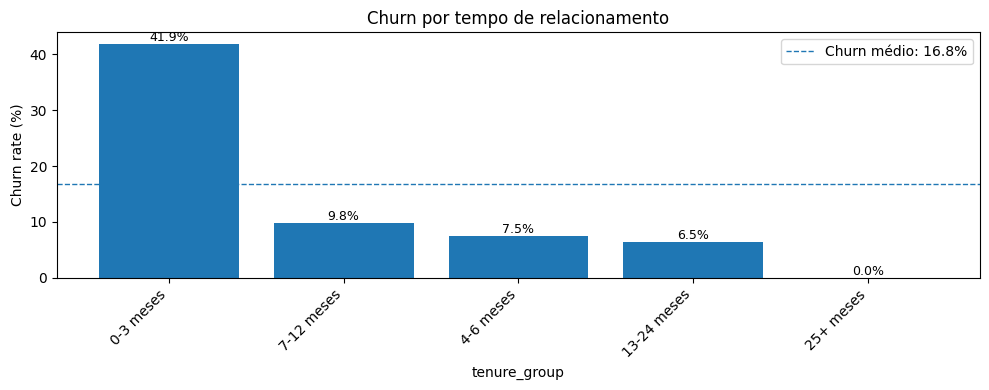


Maior risco identificado em: 0-3 meses

Churn do grupo: 41.9%
Churn médio da base: 16.8%
Lift vs média: 2.49x
Participação do grupo na base: 27.7%
Clientes no grupo: 1560
Clientes em churn no grupo: 653



In [10]:
# Churn x Tempo de relacionamento
summary_tenure = churn_summary(df_fe, "tenure_group")

display(summary_tenure)

plot_churn_summary(
    summary_tenure,
    "tenure_group",
    "Churn por tempo de relacionamento"
)

print(business_insight(summary_tenure, "tenure_group"))

## Insight — Tempo de relacionamento

Clientes com até 3 meses de relacionamento apresentaram churn de 41,9%, muito acima da média geral da base, de 16,84%.

Esse resultado indica que o maior problema de churn da ShopMais está concentrado na fase inicial da jornada do cliente. Clientes novos ainda não desenvolveram hábito de compra, recorrência ou vínculo com a plataforma, tornando-se mais sensíveis a atritos iniciais como prazo, atendimento, experiência no aplicativo e percepção de valor.

Além disso, o churn cai significativamente conforme o tempo de relacionamento aumenta, sugerindo que clientes antigos tendem a se tornar mais estáveis e recorrentes.

### Recomendações

- criar régua de onboarding nos primeiros 90 dias;
- incentivar a segunda compra;
- acompanhar a primeira experiência do cliente;
- criar campanhas de ativação para novos clientes;
- monitorar clientes novos com baixa atividade.

,complained,customers,churned,churn_rate,churn_rate_pct,base_pct,lift_vs_avg
1,1,1604,508,0.32,31.67,28.49,1.88
0,0,4026,440,0.11,10.93,71.51,0.65


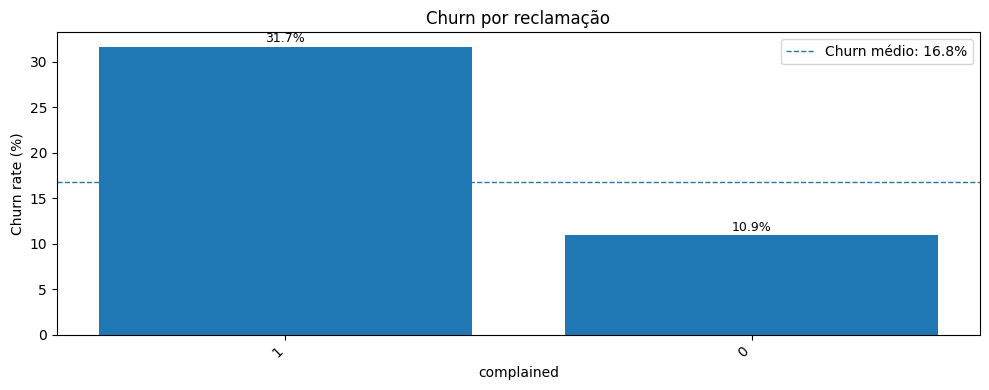


Maior risco identificado em: 1.0

Churn do grupo: 31.7%
Churn médio da base: 16.8%
Lift vs média: 1.88x
Participação do grupo na base: 28.5%
Clientes no grupo: 1604
Clientes em churn no grupo: 508



In [11]:
# Churn x Reclamação
summary_complaint = churn_summary(df_fe, "complained")

display(summary_complaint)

plot_churn_summary(
    summary_complaint,
    "complained",
    "Churn por reclamação"
)

print(business_insight(summary_complaint, "complained"))

## Insight — Reclamações como sinal crítico de risco

Clientes que registraram reclamação apresentaram churn de 31,67%, enquanto clientes sem reclamação tiveram churn de apenas 10,93%.

Na prática, clientes com reclamação apresentam quase 3 vezes mais churn do que clientes sem reclamação, indicando que a reclamação é um dos sinais mais fortes de risco identificados na análise.

Esse resultado mostra que reclamações não devem ser tratadas apenas como problemas operacionais, mas como eventos críticos de retenção.

### Recomendações

- criar fila prioritária para clientes que reclamaram;
- definir SLA(Acordo de Nível de Serviço) específico para resolução;
- realizar acompanhamento pós-atendimento;
- monitorar recompra após resolução da reclamação;
- integrar CRM(Gestão de Relacionamento com o Cliente) e atendimento para ações preventivas.

,satisfaction_group,customers,churned,churn_rate,churn_rate_pct,base_pct,lift_vs_avg
2,alta satisfação,2182,448,0.21,20.53,38.76,1.22
1,satisfação neutra,1698,292,0.17,17.20,30.16,1.02
0,baixa satisfação,1750,208,0.12,11.89,31.08,0.71


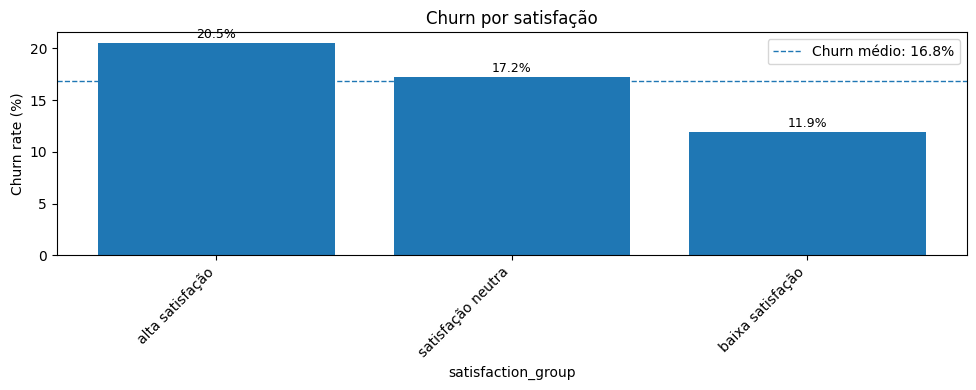


Maior risco identificado em: alta satisfação

Churn do grupo: 20.5%
Churn médio da base: 16.8%
Lift vs média: 1.22x
Participação do grupo na base: 38.8%
Clientes no grupo: 2182
Clientes em churn no grupo: 448



In [12]:
# Churn x Satisfação
summary_satisfaction = churn_summary(df_fe, "satisfaction_group")

display(summary_satisfaction)

plot_churn_summary(
    summary_satisfaction,
    "satisfaction_group",
    "Churn por satisfação"
)

print(business_insight(summary_satisfaction, "satisfaction_group"))

## Insight — Satisfação isolada não explica churn

A análise por satisfação apresentou um comportamento aparentemente contraintuitivo: clientes classificados com alta satisfação apresentaram churn de 20,5%, enquanto clientes com baixa satisfação tiveram churn de 11,9%.

Esse resultado sugere que satisfação isoladamente não é um bom indicador de retenção.

Existem algumas hipóteses para esse comportamento:

1. satisfação pode representar apenas uma experiência pontual;
2. clientes satisfeitos podem ainda não ter desenvolvido recorrência;
3. a variável de satisfação pode não medir fidelização;
4. outros fatores, como reclamações e tempo de relacionamento, parecem ter impacto maior sobre churn.

Os resultados seguintes reforçam essa hipótese, mostrando que reclamações possuem maior influência no churn do que satisfação isolada.

### Recomendações

- evitar usar satisfação isoladamente como indicador principal de retenção;
- combinar satisfação com reclamações, recência e comportamento de compra;
- investigar possíveis inconsistências ou limitações da variável de satisfação;
- utilizar modelos multivariados para interpretar churn.

,recency_group,customers,churned,churn_rate,churn_rate_pct,base_pct,lift_vs_avg
3,31+ dias,2,1,0.50,50.00,0.04,2.97
0,0-7 dias,4328,825,0.19,19.06,76.87,1.13
1,8-15 dias,1259,122,0.10,9.69,22.36,0.58
2,16-30 dias,41,0,0.00,0.00,0.73,0.00


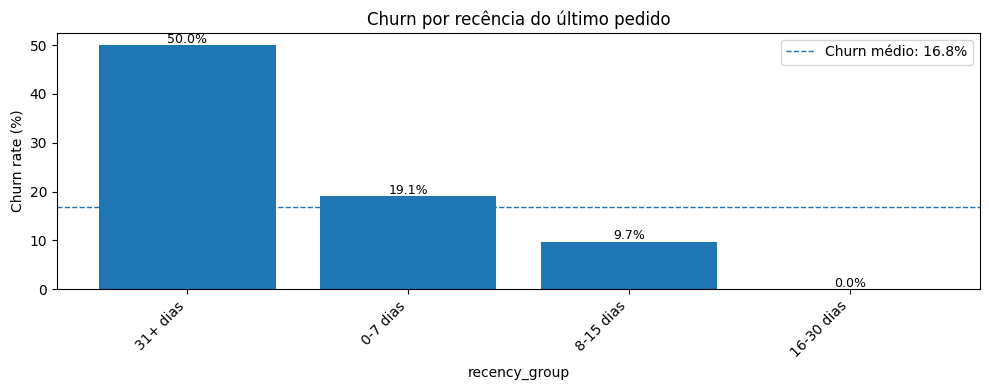


Maior risco identificado em: 31+ dias

Churn do grupo: 50.0%
Churn médio da base: 16.8%
Lift vs média: 2.97x
Participação do grupo na base: 0.0%
Clientes no grupo: 2
Clientes em churn no grupo: 1



In [13]:
#Churn vs recência do último pedido
summary_recency = churn_summary(df_fe, "recency_group")

display(summary_recency)

plot_churn_summary(
    summary_recency,
    "recency_group",
    "Churn por recência do último pedido"
)

print(business_insight(summary_recency, "recency_group"))

## Insight — Inatividade recente aumenta risco de churn

Clientes com mais de 31 dias desde o último pedido apresentaram churn de 50%, muito acima da média geral da base.

O resultado indica que aumento no tempo sem compra está associado a maior risco de abandono da plataforma.

No entanto, esse grupo parece possuir volume reduzido de clientes, o que exige cautela na interpretação do percentual. Mesmo assim, a recência continua sendo uma variável relevante para ações de CRM e reativação.

### Recomendações

- criar campanhas automáticas de reativação;
- ativar comunicação após 15 dias sem compra;
- intensificar campanhas após 30 dias;
- testar incentivos personalizados;
- monitorar recência em conjunto com frequência de compra.

,complaint_satisfaction_risk,customers,churned,churn_rate,churn_rate_pct,base_pct,lift_vs_avg
3,reclamou + média/alta satisfação,1062,388,0.37,36.53,18.86,2.17
2,reclamou + baixa satisfação,542,120,0.22,22.14,9.63,1.31
1,não reclamou + média/alta satisfação,2818,352,0.12,12.49,50.05,0.74
0,não reclamou + baixa satisfação,1208,88,0.07,7.28,21.46,0.43


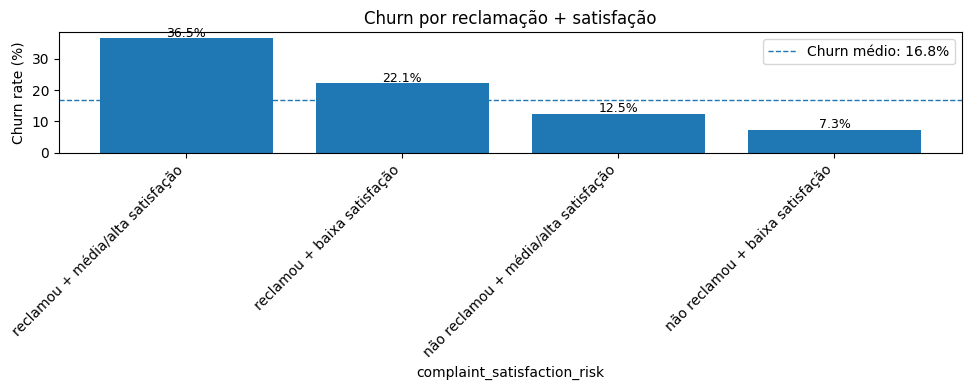


Maior risco identificado em: reclamou + média/alta satisfação

Churn do grupo: 36.5%
Churn médio da base: 16.8%
Lift vs média: 2.17x
Participação do grupo na base: 18.9%
Clientes no grupo: 1062
Clientes em churn no grupo: 388



In [14]:
# Churn x Satisfação + reclamação
summary_complaint_satisfaction = churn_summary(
    df_fe,
    "complaint_satisfaction_risk"
)

display(summary_complaint_satisfaction)

plot_churn_summary(
    summary_complaint_satisfaction,
    "complaint_satisfaction_risk",
    "Churn por reclamação + satisfação"
)

print(business_insight(summary_complaint_satisfaction, "complaint_satisfaction_risk"))

## Insight — Reclamação pesa mais que satisfação

Ao combinar reclamação e satisfação, observa-se que clientes que reclamaram apresentam churn elevado independentemente do nível de satisfação declarado.

O grupo “reclamou + média/alta satisfação” apresentou churn de 36,5%, enquanto clientes que não reclamaram e possuem média/alta satisfação tiveram churn de apenas 12,5%.

Esse resultado sugere que a existência de uma reclamação é um sinal de risco mais forte do que o score de satisfação isolado.

Além disso, esse comportamento ajuda a explicar por que clientes classificados como satisfeitos ainda apresentam churn elevado: parte deles pertence ao grupo de clientes que reclamaram anteriormente.

### Recomendações

- priorizar clientes que reclamaram em estratégias de retenção;
- monitorar churn pós-reclamação;
- criar atendimento preventivo para clientes com histórico de reclamação;
- usar satisfação apenas em conjunto com outras variáveis.

,risk_segment,customers,churned,churn_rate,churn_rate_pct,base_pct,lift_vs_avg
4,novo + reclamou + baixa satisfação,166,100,0.60,60.24,2.95,3.58
2,inativo recente,2,1,0.50,50.00,0.04,2.97
0,cliente novo,1393,552,0.40,39.63,24.74,2.35
1,demais clientes,2631,201,0.08,7.64,46.73,0.45
5,sensível a desconto,1062,74,0.07,6.97,18.86,0.41
3,insatisfeito crítico,376,20,0.05,5.32,6.68,0.32


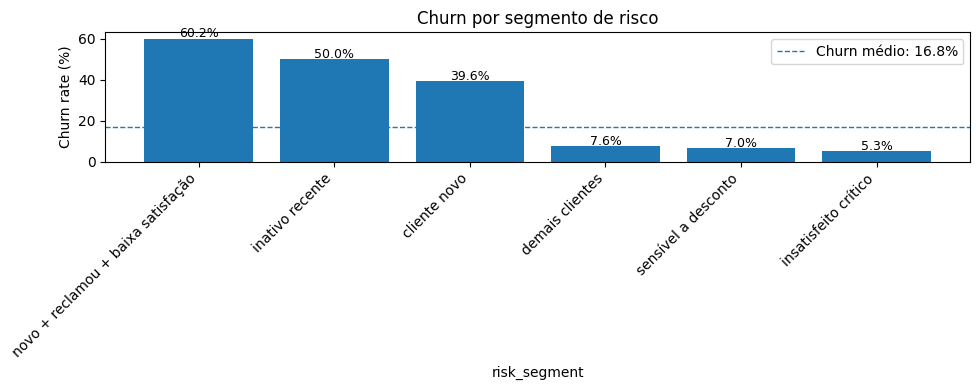


Maior risco identificado em: novo + reclamou + baixa satisfação

Churn do grupo: 60.2%
Churn médio da base: 16.8%
Lift vs média: 3.58x
Participação do grupo na base: 2.9%
Clientes no grupo: 166
Clientes em churn no grupo: 100



In [15]:
# Churn x segmento de risco
summary_risk_segment = churn_summary(df_fe, "risk_segment")

display(summary_risk_segment)

plot_churn_summary(
    summary_risk_segment,
    "risk_segment",
    "Churn por segmento de risco"
)

print(business_insight(summary_risk_segment, "risk_segment"))

In [16]:
# Tabela de priorização
priority_table = summary_risk_segment.copy()

priority_table["priority"] = np.select(
    [
        (priority_table["lift_vs_avg"] >= 1.5) & (priority_table["base_pct"] >= 10),
        (priority_table["lift_vs_avg"] >= 1.3) & (priority_table["base_pct"] >= 5),
        (priority_table["lift_vs_avg"] >= 1.0)
    ],
    [
        "alta prioridade",
        "média prioridade",
        "monitorar"
    ],
    default="baixa prioridade"
)

priority_table = priority_table.sort_values(
    by=["priority", "lift_vs_avg", "customers"],
    ascending=[True, False, False]
)

display(priority_table)

,risk_segment,customers,churned,churn_rate,churn_rate_pct,base_pct,lift_vs_avg,priority
0,cliente novo,1393,552,0.40,39.63,24.74,2.35,alta prioridade
1,demais clientes,2631,201,0.08,7.64,46.73,0.45,baixa prioridade
5,sensível a desconto,1062,74,0.07,6.97,18.86,0.41,baixa prioridade
3,insatisfeito crítico,376,20,0.05,5.32,6.68,0.32,baixa prioridade
4,novo + reclamou + baixa satisfação,166,100,0.60,60.24,2.95,3.58,monitorar
2,inativo recente,2,1,0.50,50.00,0.04,2.97,monitorar


## Insight — Segmentação de risco

O segmento “cliente novo” apresentou churn de 39,63%, representando 24,74% da base total de clientes.

Esse resultado torna o grupo de clientes novos o principal foco estratégico de retenção da ShopMais, pois combina:

- churn elevado;
- grande volume de clientes;
- alto impacto potencial no resultado da empresa.

O segmento “novo + reclamou + baixa satisfação” apresentou o maior churn da análise, com 60,24%. Porém, representa apenas 2,95% da base.

Isso significa que esse grupo possui alta severidade individual, mas impacto agregado menor quando comparado ao segmento amplo de clientes novos.

### Recomendações

#### Prioridade estratégica
Clientes novos:
- onboarding;
- incentivo à segunda compra;
- comunicação preventiva;
- acompanhamento inicial.

#### Monitoramento intensivo
Clientes novos com reclamação e baixa satisfação:
- atendimento humano prioritário;
- recuperação preventiva;
- acompanhamento individual;
- monitoramento de reincidência.

# Conclusão Executiva

A análise indica que o churn da ShopMais está fortemente concentrado nos primeiros meses de relacionamento do cliente.

O principal fator estrutural identificado foi o baixo tempo de relacionamento, enquanto reclamações apareceram como o sinal operacional mais forte de risco.

Os resultados sugerem que a empresa deve concentrar esforços em:

1. onboarding e ativação inicial;
2. retenção nos primeiros 90 dias;
3. acompanhamento de clientes com reclamação;
4. campanhas preventivas de reativação;
5. monitoramento contínuo de segmentos de risco.

A análise também mostrou que satisfação isoladamente não explica bem o churn, reforçando a necessidade de análises multivariadas e segmentação comportamental.

O segmento de maior impacto para o negócio é o de clientes novos, que combina alto churn e grande participação na base.